# Polynomial Model — YOLOv8 Segmentation Training

Trains a YOLOv8 instance-segmentation model on the labeled finger dataset.

**Dataset:** `data/processed/2026-04-23-07-45_Polynomial_Model/`  
**Format:** YOLO segmentation (polygon keypoints per finger)  
**Classes:** `right-hand-index` · `right-hand-middle` · `right-hand-thumb`

## 0 · Setup

In [2]:
import sys, os
from pathlib import Path

# Add project root to path
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)

Project root: C:\Users\admin\Desktop\R\Projects\05_CV\Hand_Pose_Estimation


In [3]:
# Install / verify dependencies
# !pip install ultralytics --quiet

import ultralytics
print("Ultralytics version:", ultralytics.__version__)

import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Ultralytics version: 8.4.39
PyTorch version: 2.10.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4090


## 1 · Inspect Dataset

In [4]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np

DATASET_DIR = ROOT / "data/processed/2026-04-23-07-45_Polynomial_Model"
images = sorted((DATASET_DIR / "images").glob("*.jpg"))
labels = sorted((DATASET_DIR / "labels").glob("*.txt"))

print(f"Images : {len(images)}")
print(f"Labels : {len(labels)}")

with open(DATASET_DIR / "notes.json") as f:
    notes = json.load(f)
print("\nClasses:")
for c in notes["categories"]:
    print(f"  {c['id']}: {c['name']}")

Images : 73
Labels : 74

Classes:
  0: right-hand-index
  1: right-hand-middle
  2: right-hand-thumb


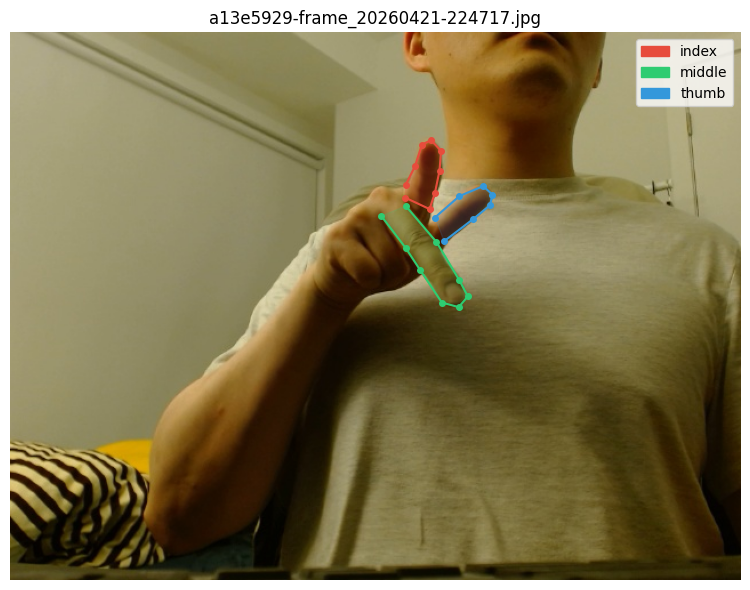

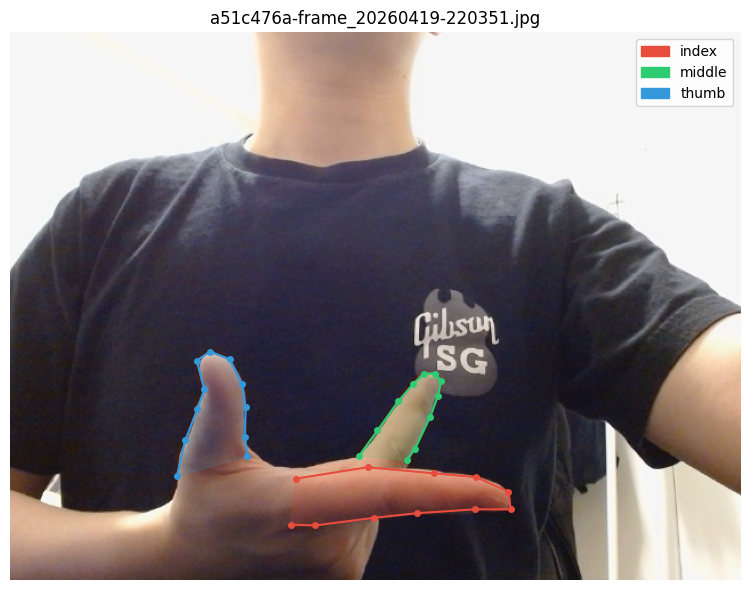

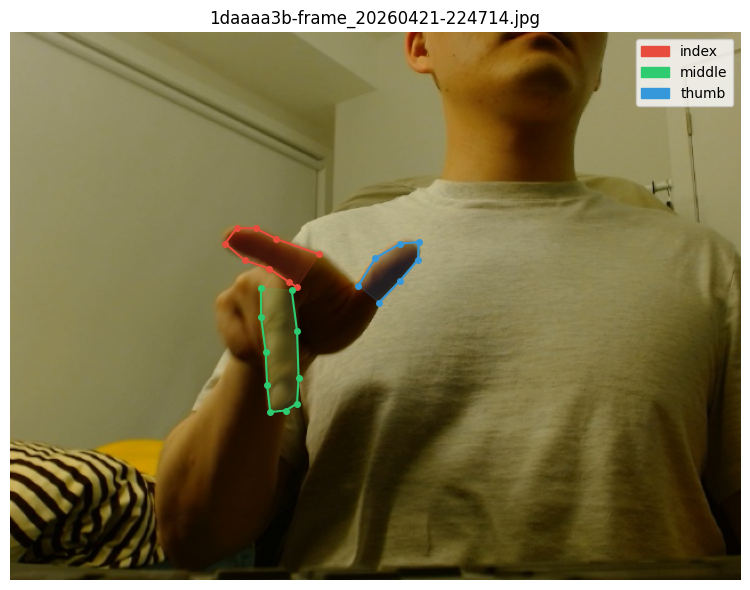

In [5]:
CLASS_COLORS = {0: "#e74c3c", 1: "#2ecc71", 2: "#3498db"}
CLASS_NAMES  = {0: "index", 1: "middle", 2: "thumb"}

def show_sample(img_path):
    label_path = DATASET_DIR / "labels" / img_path.with_suffix(".txt").name
    img = np.array(Image.open(img_path))
    h, w = img.shape[:2]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)

    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            vals = list(map(float, line.split()))
            cls  = int(vals[0])
            coords = np.array(vals[1:]).reshape(-1, 2)
            xs = coords[:, 0] * w
            ys = coords[:, 1] * h
            color = CLASS_COLORS[cls]
            ax.plot(xs, ys, "o-", color=color, linewidth=1.5, markersize=4, label=CLASS_NAMES[cls])
            ax.fill(xs, ys, alpha=0.15, color=color)

    handles = [mpatches.Patch(color=v, label=CLASS_NAMES[k]) for k, v in CLASS_COLORS.items()]
    ax.legend(handles=handles, loc="upper right")
    ax.set_title(img_path.name)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Show 3 random samples
import random
random.seed(0)
for p in random.sample(images, min(3, len(images))):
    show_sample(p)

## 2 · Prepare Train / Val Split

In [6]:
import importlib
import src.training.train_polynomial_model as _tm
importlib.reload(_tm)

from src.training.train_polynomial_model import prepare_split, SPLIT_DIR, DATASET_YAML

prepare_split(val_ratio=0.2, seed=42, force=False)

n_train = len(list((SPLIT_DIR / "images/train").glob("*")))
n_val   = len(list((SPLIT_DIR / "images/val").glob("*")))
print(f"Train: {n_train}  Val: {n_val}")
print(f"Dataset YAML: {DATASET_YAML}")

Split already exists at C:\Users\admin\Desktop\R\Projects\05_CV\Hand_Pose_Estimation\data\processed\2026-04-23-07-45_Polynomial_Model\yolo_split. Use --force to rebuild.
Train: 59  Val: 14
Dataset YAML: C:\Users\admin\Desktop\R\Projects\05_CV\Hand_Pose_Estimation\data\processed\2026-04-23-07-45_Polynomial_Model\yolo_split\dataset.yaml


## 3 · Train YOLOv8-seg

In [7]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
MODEL_NAME = "yolov8n-seg"   # n=nano (fast), s=small, m=medium, l=large, x=extra-large
EPOCHS     = 250
IMGSZ      = 640
BATCH      = 32              # lower if GPU OOM
LR0        = 0.001        # initial learning rate (default 0.01 for SGD, 0.001 for Adam)
WEIGHT_DECAY = 0.0005         # L2 regularization
AUGMENT    = True            # apply data augmentation
PATIENCE   = 300           # early-stop if val metric doesn't improve
DEVICE     = ""              # "" = auto (GPU if available, else CPU)
# ─────────────────────────────────────────────────────────────────────────────

In [7]:
import sys
from ultralytics import YOLO

model = YOLO(MODEL_NAME)

# Ultralytics reads sys.argv; in Jupyter that contains --f=<kernel.json>
# which it tries to parse as a YOLO argument. Clear it before training.
_saved_argv = sys.argv.copy()
sys.argv = sys.argv[:1]

try:
    results = model.train(
        data=str(DATASET_YAML.resolve()),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        lr0=LR0,
        patience=PATIENCE,
        device=DEVICE if DEVICE else None,
        project=str(ROOT / "runs/polynomial_model"),
        name="train",
        exist_ok=True,
        seed=42,
        optimizer="Adam",       # was "optimize" (typo) — correct key is "optimizer"
        # augmentation — important for small datasets
        flipud=0.0,
        fliplr=0.5,
        degrees=10.0,
        translate=0.1,
        scale=0.3,
        mosaic=1.0,
        mixup=0.0,
        # drop_block is not a valid YOLO argument — removed
    )
finally:
    sys.argv = _saved_argv

print("\nBest model saved to:", results.save_dir)

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.39  Python-3.12.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\admin\Desktop\R\Projects\05_CV\Hand_Pose_Estimation\data\processed\2026-04-23-07-45_Polynomial_Model\yolo_split\dataset.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=250, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, 

## 4 · Training Curves

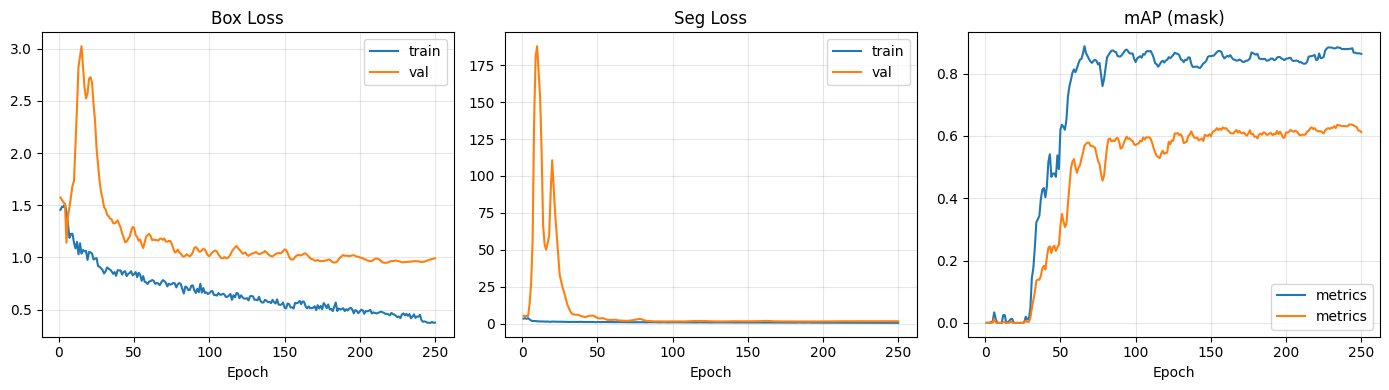

In [11]:
import pandas as pd

results_csv = Path(results.save_dir) / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

metrics = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/seg_loss", "val/seg_loss", "Seg Loss"),
    ("metrics/mAP50(M)", "metrics/mAP50-95(M)", "mAP (mask)"),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(14, 4))
for ax, (col1, col2, title) in zip(axes, metrics):
    if col1 in df.columns:
        ax.plot(df["epoch"], df[col1], label=col1.split("/")[0])
    if col2 in df.columns:
        ax.plot(df["epoch"], df[col2], label=col2.split("/")[0])
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5 · Validate Best Model

In [12]:
best_pt = Path(results.save_dir) / "weights/best.pt"
print("Loading best weights from:", best_pt)

best_model = YOLO(str(best_pt))
val_metrics = best_model.val(data=str(DATASET_YAML.resolve()), split="val")
print(val_metrics)

Loading best weights from: C:\Users\admin\Desktop\R\Projects\05_CV\Hand_Pose_Estimation\runs\polynomial_model\train\weights\best.pt
Ultralytics 8.4.39  Python-3.12.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,649 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 628.5337.5 MB/s, size: 56.6 KB)
val: Scanning C:\Users\admin\Desktop\R\Projects\05_CV\Hand_Pose_Estimation\data\processed\2026-04-23-07-45_Polynomial_Model\yolo_split\labels\val.cache... 14 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14/14  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4s/it 1.4s
                   all         14         41      0.945       0.76      0.855      0.639      0.945       0.76       0.88      0.637
      right-hand-index         14         14      0.872      0.786      0.838   

## 6 · Inference on Val Images

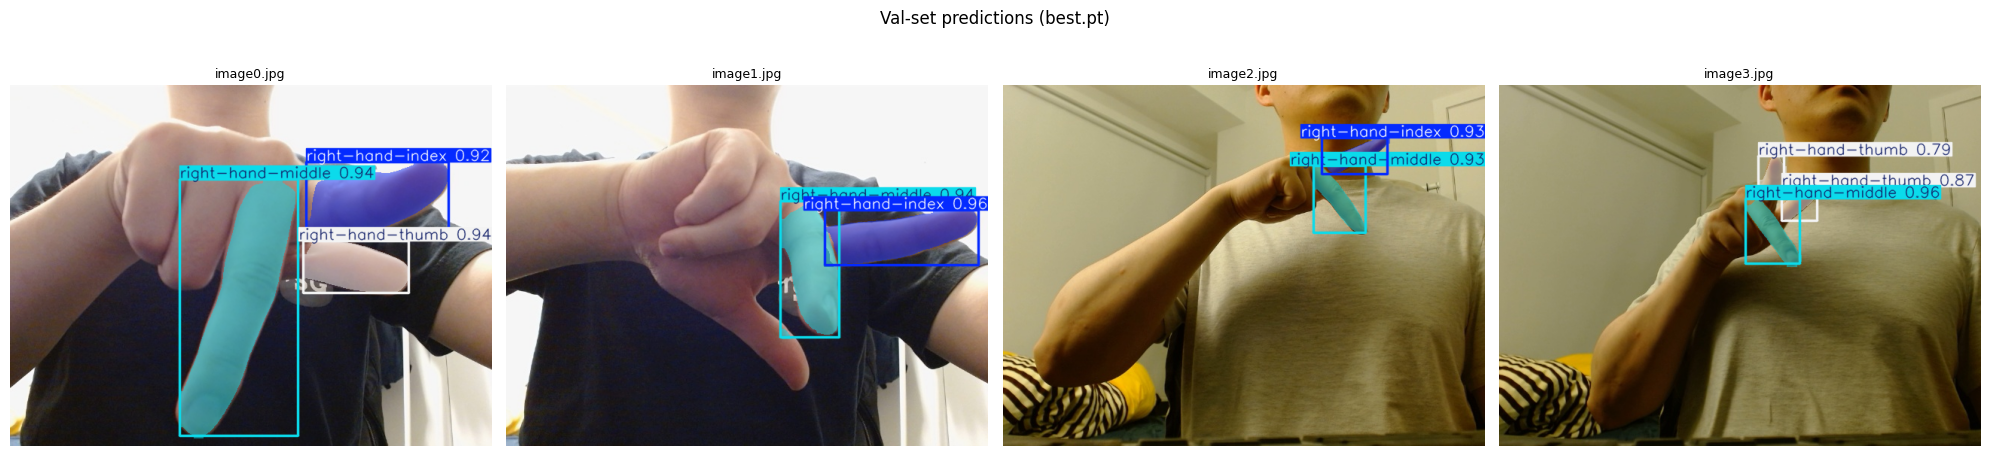

In [13]:
val_images = list((SPLIT_DIR / "images/val").glob("*.jpg"))
sample_imgs = random.sample(val_images, min(4, len(val_images)))

preds = best_model.predict(sample_imgs, conf=0.25, iou=0.45, verbose=False)

fig, axes = plt.subplots(1, len(preds), figsize=(5 * len(preds), 5))
if len(preds) == 1:
    axes = [axes]

for ax, result in zip(axes, preds):
    img_bgr = result.plot()               # BGR numpy array with masks + boxes
    ax.imshow(img_bgr[:, :, ::-1])        # convert BGR → RGB
    ax.set_title(Path(result.path).name, fontsize=9)
    ax.axis("off")

plt.suptitle("Val-set predictions (best.pt)", fontsize=12)
plt.tight_layout()
plt.show()

## 7 · Live Webcam Inference

Each cell below is **self-contained** — you can run them without re-running the whole notebook.  
A native OpenCV window will open. **Press `Q` inside that window to stop.**

Model loaded: C:\Users\admin\Desktop\R\Projects\05_CV\Hand_Pose_Estimation\runs\polynomial_model\train\weights\best.pt


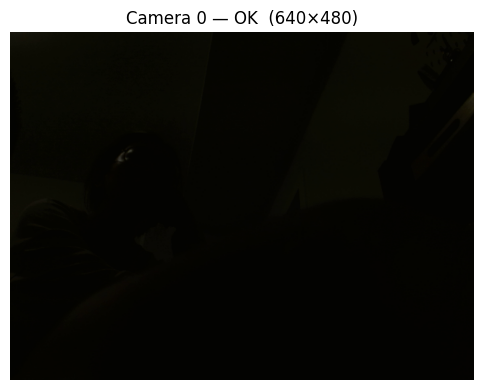

Camera OK. Run the next cell to start live inference.


In [1]:
# ── 7a · Load model & verify camera ──────────────────────────────────────────
import sys, cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
# Self-contained: resolve project root from this notebook's location
ROOT = Path().resolve().parent
MODEL_PATH  = ROOT / "runs/polynomial_model/train/weights/best.pt"
CAMERA_ID   = 0      # change to 1, 2 … if this isn't your hand camera
CONF_THRESH = 0.35

# -- load model ----------------------------------------------------------------
if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"No model at {MODEL_PATH}\n"
        "Run Section 3 (training) first."
    )

_argv = sys.argv.copy()
sys.argv = sys.argv[:1]
webcam_model = YOLO(str(MODEL_PATH))
sys.argv = _argv
print("Model loaded:", MODEL_PATH)

# -- verify camera -------------------------------------------------------------
cap = cv2.VideoCapture(CAMERA_ID, cv2.CAP_DSHOW)
if not cap.isOpened():
    raise RuntimeError(
        f"Cannot open camera {CAMERA_ID}.\n"
        "Try changing CAMERA_ID to 1 or 2."
    )

ok, test_frame = cap.read()
cap.release()

if not ok:
    raise RuntimeError("Camera opened but could not read a frame.")

# show one frame inline to confirm the camera is working
plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB))
plt.title(f"Camera {CAMERA_ID} — OK  ({test_frame.shape[1]}×{test_frame.shape[0]})")
plt.axis("off")
plt.tight_layout()
plt.show()
print("Camera OK. Run the next cell to start live inference.")

In [ ]:
# ── 7b · Live inference loop ──────────────────────────────────────────────────
# Requires 7a to have run first (webcam_model, CAMERA_ID, CONF_THRESH).
# A native window opens — press Q inside it to stop.
import cv2, sys, time

cap = cv2.VideoCapture(CAMERA_ID, cv2.CAP_DSHOW)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT,  720)

WIN = "Finger Segmentation  [Q = quit]"
cv2.namedWindow(WIN, cv2.WINDOW_NORMAL)
cv2.resizeWindow(WIN, 960, 540)

t0 = time.time()
n_frames = 0
fps = 0.0

_argv = sys.argv.copy()
sys.argv = sys.argv[:1]

try:
    while True:
        ok, frame = cap.read()
        if not ok:
            print("Frame read failed — stopping.")
            break

        # inference
        res       = webcam_model.predict(frame, conf=CONF_THRESH, iou=0.45, verbose=False)[0]
        annotated = res.plot()   # BGR with masks + boxes

        # FPS counter
        n_frames += 1
        elapsed = time.time() - t0
        if elapsed >= 1.0:
            fps      = n_frames / elapsed
            n_frames = 0
            t0       = time.time()

        # HUD
        n_det = len(res.boxes) if res.boxes is not None else 0
        cv2.putText(
            annotated,
            f"FPS {fps:.1f}   det {n_det}   [Q quit]",
            (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9,
            (255, 255, 255), 2, cv2.LINE_AA,
        )

        cv2.imshow(WIN, annotated)

        # Q or window-close → stop
        key = cv2.waitKey(1) & 0xFF
        if key == ord("q") or cv2.getWindowProperty(WIN, cv2.WND_PROP_VISIBLE) < 1:
            break

finally:
    sys.argv = _argv
    cap.release()
    cv2.destroyAllWindows()
    print("Webcam closed.")

Webcam closed.
